# NLP Zero To Hero Part 5: Long Short Term Memory for NLP

* When prediciting text where context is FAR BACK.
  - EX: "I lived in Ireland, so at school they made me learn how to speak..."

      - Notice how we trace ALL THE WAY back to "Ireland" to predict "Gaelic".

* Looking FAR BACK, may be HARD to achieve for RNNs.

* Over LONG distances, context can be greatly diluted.

* LSTM architecture can help here ^.
  - Introduces a cell state. CONTEXT that can be maintained across many timestamps.

  - Can bring meaning from the beginning of the sentence.

  - Can be BIDIRECTIONAL where LATER words in the sentence can also provide context to EARLIER ones. ENables us to learn the semantics of a sentence more accurately.

  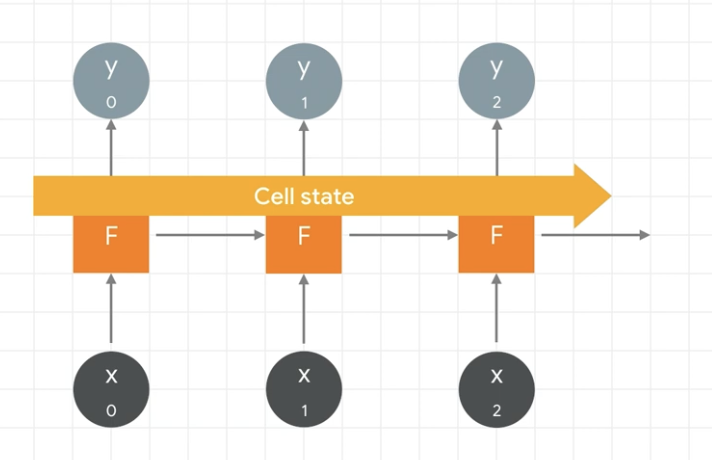

## LSTM in the Sarcasm Classifier

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
nltk.download('punkt_tab')
import json

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/svenwu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
vocab_size = 10000
embedding_dim = 16
max_length = 100
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
training_size = 20000

In [3]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/sarcasm.json \
    -O /tmp/sarcasm.json


--2026-09-12 14:32:37--  https://storage.googleapis.com/learning-datasets/sarcasm.json
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.210.155, 142.251.219.155, 142.251.218.91, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.210.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5643545 (5.4M) [application/json]
Saving to: '/tmp/sarcasm.json'

/tmp/sarcasm.json   100%[===================>]   5.38M  2.64MB/s    in 2.0s    

2026-09-12 14:32:39 (2.64 MB/s) - '/tmp/sarcasm.json' saved [5643545/5643545]



In [4]:
with open("/tmp/sarcasm.json", 'r') as f:
    datastore = json.load(f)

sentences = []
labels = []
urls = []

for item in datastore:
    sentences.append(item['headline'])
    labels.append(item['is_sarcastic'])
    urls.append(item['article_link'])

In [5]:
tokenizer = Tokenizer(oov_token="<OOV>")
# Calling "fit" on texts with the "Headlines", enables us to create tokens for every word in the corpus.
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index

sequences = tokenizer.texts_to_sequences(sentences)
padded = pad_sequences(sequences, padding='post')
print(padded[0])
# We will get 26709 sequences, each with 40 tokens.
print(padded.shape)

[  308 15115   679  3337  2298    48   382  2576 15116     6  2577  8434
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]
(26709, 40)


### Split into training and testing data.

In [6]:
print(f'Length of sentences: {len(sentences)}')
print(f'Length of labels: {len(labels)}')
print(f'Length of URLs: {len(urls)}')


Length of sentences: 26709
Length of labels: 26709
Length of URLs: 26709


In [7]:
# Training Size of 20000 chosen.
training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]

# Same with labels
training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

### Rewrite Code, so it is only FIT TO THE TRAINING DATA.
* Not the testing data.

In [8]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
# Fit tokenizer on just the training sentences.
tokenizer.fit_on_texts(training_sentences)

word_index = tokenizer.word_index

# Create a set of training sequences, and pad them.
training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, maxlen=max_length, 
                                padding=padding_type, truncating=trunc_type)

# Create a set of testing sequences, and pad them.
testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, 
                               padding=padding_type, truncating=trunc_type)

In [9]:
# Need this block to get it to work with TensorFlow 2.x
# CONVERT the four datasets into NumPy ARRAYS:
# This gives Keras/TensorFlow a DATA TYPE it could recognize for model.fit().
import numpy as np
training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
testing_padded = np.array(testing_padded)
testing_labels = np.array(testing_labels)

In [11]:
model = tf.keras.Sequential([
  tf.keras.layers.Embedding(vocab_size, 64), 
  
  # Bidirectional will look at sentences forward and backwards. learn the best parameters for each, and then merge them.
  tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)), 
  
  tf.keras.layers.Dense(64, activation='relu'), 
   
  tf.keras.layers.Dense(1, activation='sigmoid')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)